# Import libraries

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from tqdm import tqdm

from sklearn.metrics import silhouette_samples, silhouette_score


# Loading the data

In [3]:
save_directory = './preprocessed_dataset/VG5/op_0'

control_df = pd.read_parquet(path=f'{save_directory}/control.parquet')
sensors_heat_exchanger = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
training_df = pd.concat([control_df,sensors_heat_exchanger], axis=1)

print(training_df.shape)

(99218, 16)


# Clustering

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
training_transformed = kmeans.fit_transform(training_df[::50])

In [ ]:
labels = kmeans.predict(training_df[::50])

In [39]:
print(f'The number of points that are in the first cluster : {len(labels[labels==0])}')
print(f'The number of points that are in the second cluster : {len(labels[labels==1])}')

The number of points that are in the first cluster : 4005
The number of points that are in the second cluster : 5917


### Silhouette score

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


For n_clusters = 2 The average silhouette_score is : 0.3712604071120493


/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


For n_clusters = 10 The average silhouette_score is : 0.2190746924406912


/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


For n_clusters = 20 The average silhouette_score is : 0.20202235557648224


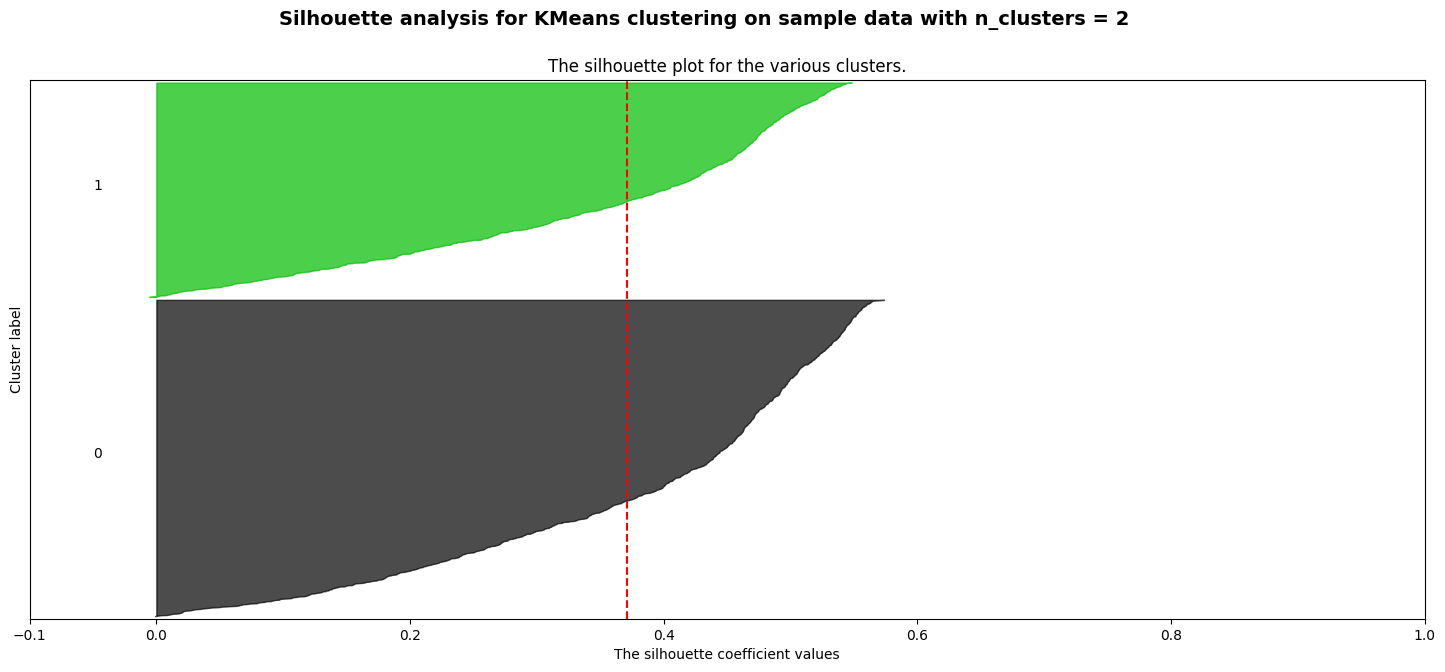

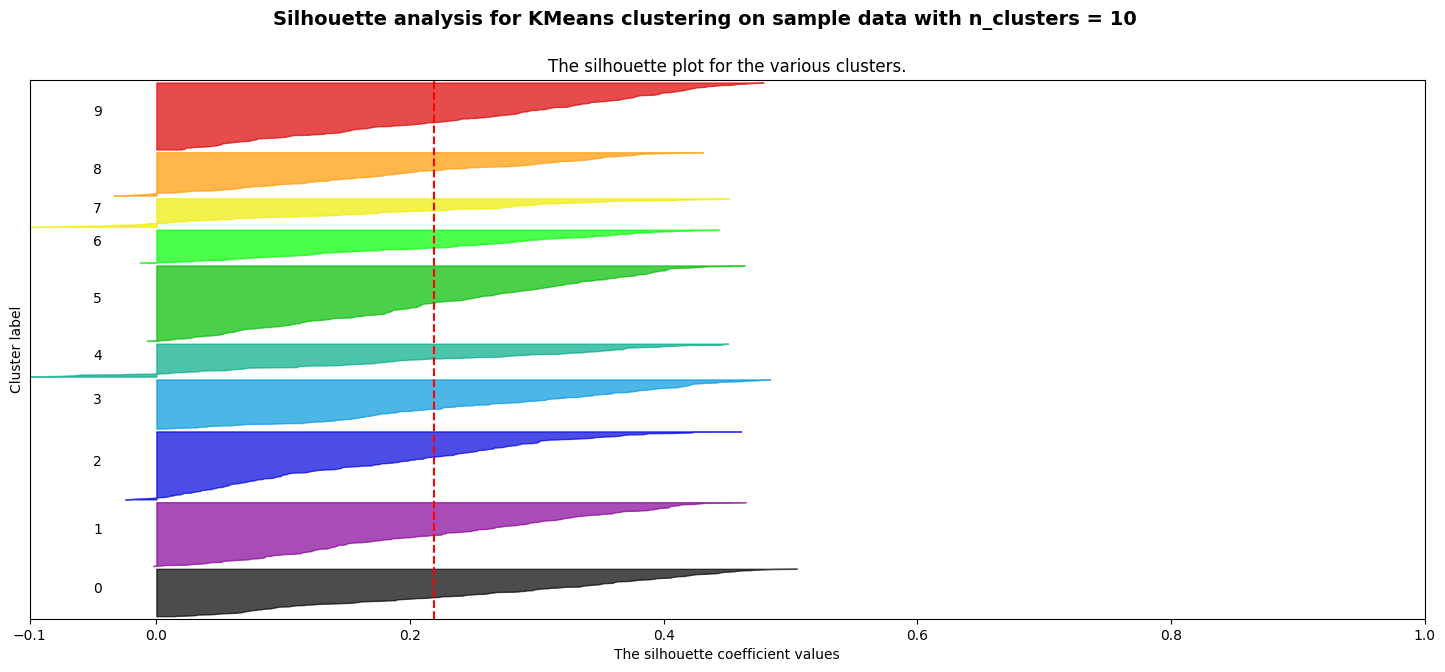

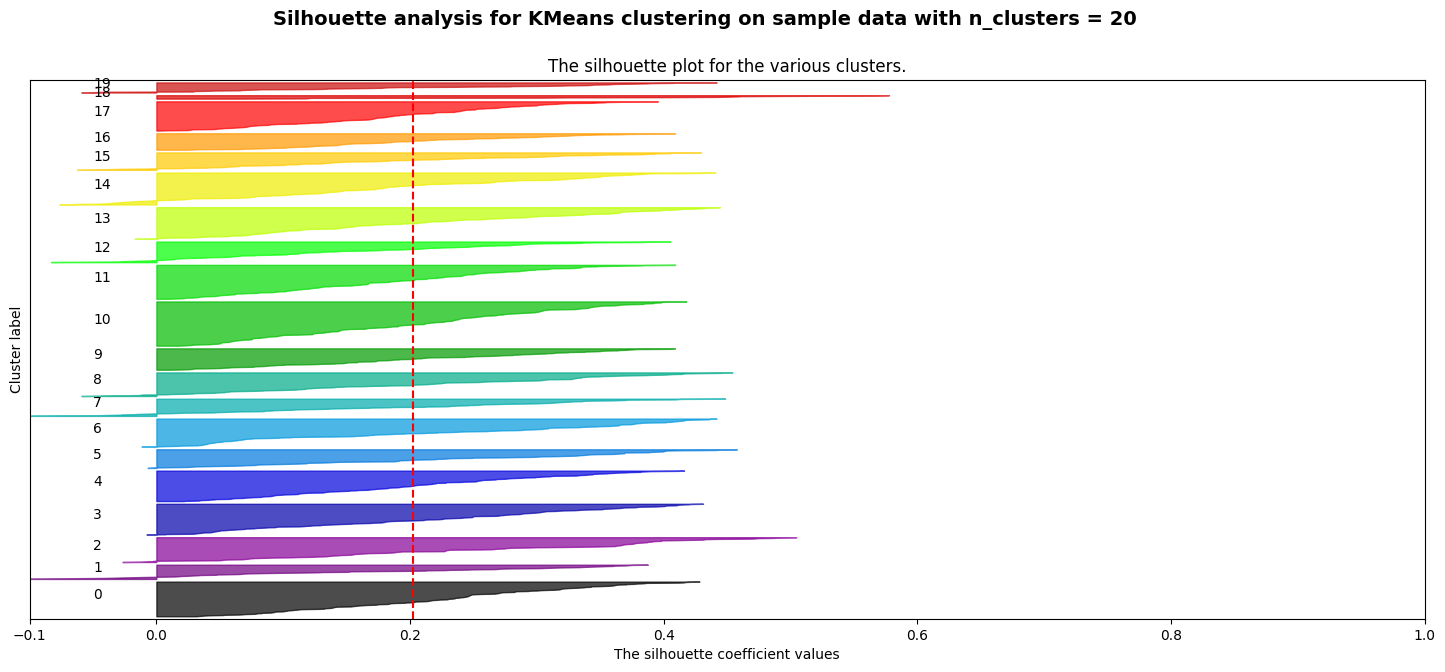

In [69]:
range_n_clusters = [2, 10 ,20]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(training_df[::50]) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(training_df[::50])

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(training_df[::50], cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(training_df[::50], cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## Other try with only one cluster

In [84]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
training_transformed = kmeans.fit_transform(training_df[::50])
cluster_labels = kmeans.predict(training_df[::50])
print(kmeans.score(training_df))
silhouette_score(training_df[::50], cluster_labels)

-9974.322173368262


0.3712604071120493

# Evaluation

In [72]:
### Evaluating on the second operation period

save_directory = './preprocessed_dataset/VG5/op_1'

valid_control = pd.read_parquet(path=f'{save_directory}/control.parquet')
valid_sensors = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
valid_df = pd.concat([valid_control,valid_sensors], axis=1)

print(valid_df.shape)

(57864, 16)


In [76]:
valid_transformed = kmeans.predict(valid_df[::50])
kmeans.score(valid_df)

-18169.737223861717

In [77]:
### Evaluating on the synthetic set

save_directory = './preprocessed_dataset/VG5/s_01'

syn_control = pd.read_parquet(path=f'{save_directory}/control.parquet')
syn_sensors = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
syn_df = pd.concat([syn_control,syn_sensors], axis=1)

print(syn_df.shape)

(45229, 16)


In [83]:
syn_transformed = kmeans.predict(syn_df)
kmeans.score(syn_df)

-71603.83745875908